
# N-gram Language Models

*A lecture note on the original statistical approach to "what word comes
next" — the ancestor every neural language model (RNN, LSTM, transformer)
was built to replace, and whose core ideas (context windows, backoff,
perplexity) are still baked into how we evaluate and use language models
today.*

---

## 1. Intro: predicting the next word is an old problem

Every time your phone keyboard suggests the next word, or a search engine
finishes your query before you do, something is solving the same problem:
**given the words so far, what word is most likely to come next?**

Long before neural networks were practical for this, statisticians had a
simple, surprisingly effective answer: **count how often word sequences
occurred in a large body of text, and use those counts as probabilities.**
If the word `"York"` almost always follows `"New"` in your training text,
then `P("York" | "New")` should be high. If `"York"` never once follows
`"banana"`, that probability should be near zero.

This is a **language model**: a system that assigns a probability to a
sequence of words, or equivalently, predicts the next word given the words
that came before it. An **n-gram language model** is the simplest, most
literal version of this idea — it looks at the previous $n-1$ words only,
counts, and does division.

By the end of this tutorial you will be able to:

- State the chain rule of probability for a sentence and explain why the
  **Markov assumption** is needed to make n-gram counting tractable.
- Derive the **Maximum Likelihood Estimate** for n-gram probabilities, and
  explain the **zero-probability problem** it runs into on real text.
- Derive **Laplace / add-k smoothing** and explain (conceptually) why
  **Kneser-Ney smoothing** does better.
- Define **perplexity** and compute it for real, on held-out text.
- Build unigram, bigram, and trigram models from scratch on a real corpus,
  measure how perplexity actually changes with $n$ and with smoothing, and
  generate text from the trained models.

---

## 2. The idea, intuitively

Forget the math for a second. Suppose your entire "training data" is just
three short sentences:

> "the cat sat on the mat"
> "the dog sat on the rug"
> "the cat ran on the grass"

If someone asks "what word is most likely to follow `the`?", you don't
need probability theory to answer — you just **count**. `the` is followed
by `cat` (twice) and `dog` (once) in this tiny corpus, so `cat` is twice
as likely as `dog` to come next, and every other word (`pizza`, `Jupiter`,
`whom`) has never been seen after `the` at all, so it gets probability
zero.

That's it. That's the whole idea of an n-gram model: **turn word counts
into a probability table, and use the table to predict.** Let's do exactly
that in three lines of code before touching any formal notation.


In [1]:

from collections import Counter

toy_corpus = [
    "the cat sat on the mat".split(),
    "the dog sat on the rug".split(),
    "the cat ran on the grass".split(),
]

# Count how often each word follows "the"
followers_of_the = Counter()
for sentence in toy_corpus:
    for w1, w2 in zip(sentence, sentence[1:]):
        if w1 == "the":
            followers_of_the[w2] += 1

total = sum(followers_of_the.values())
print("Words observed right after 'the', with estimated P(word | 'the'):")
for word, count in followers_of_the.most_common():
    print(f"  P({word!r} | 'the') = {count}/{total} = {count/total:.3f}")


Words observed right after 'the', with estimated P(word | 'the'):
  P('cat' | 'the') = 2/6 = 0.333
  P('mat' | 'the') = 1/6 = 0.167
  P('dog' | 'the') = 1/6 = 0.167
  P('rug' | 'the') = 1/6 = 0.167
  P('grass' | 'the') = 1/6 = 0.167



That table **is** a bigram language model already — "bigram" just means
we conditioned on 1 previous word ($n=2$). `cat` and `dog` and `ran` split
the probability mass; every unseen word (`pizza`, `whom`, ...) silently
gets 0. That silent zero is going to come back and bite us in a few
sections — it's the single biggest practical problem with this whole
approach, and half of this tutorial is about fixing it.

Now let's make this precise.



## 3. Going deeper: the formal definition

### 3.1 The chain rule of probability

A sentence is a sequence of words $w_1, w_2, \dots, w_m$. A language model
needs to assign this whole sequence a joint probability
$P(w_1, w_2, \dots, w_m)$. By the **chain rule of probability**, any joint
distribution can be factored exactly, with no approximation, into a
product of conditionals:

$$
P(w_1, w_2, \dots, w_m) = \prod_{i=1}^{m} P(w_i \mid w_1, w_2, \dots, w_{i-1})
$$

In words: the probability of the whole sentence is the probability of the
first word, times the probability of the second word given the first,
times the probability of the third word given the first two, and so on.
This is exact — no assumption has been made yet. The problem is purely
practical: $P(w_i \mid w_1, \dots, w_{i-1})$ conditions on an
**arbitrarily long history**. To estimate it from counts we would need to
have seen the exact prefix $w_1, \dots, w_{i-1}$ before in training data,
which for anything longer than a few words essentially never happens —
every sufficiently long sentence is unique.

### 3.2 The Markov assumption

The fix is the **Markov assumption**: instead of conditioning on the
entire history, condition on only the previous $n-1$ words.

$$
P(w_i \mid w_1, \dots, w_{i-1}) \approx P(w_i \mid w_{i-n+1}, \dots, w_{i-1})
$$

This is what makes the model an **n-gram** model — $n$ is the size of the
whole window (context + the word being predicted). A **unigram** model
($n=1$) predicts each word with no context at all. A **bigram** model
($n=2$) conditions on 1 previous word (exactly what we computed above). A
**trigram** model ($n=3$) conditions on 2 previous words. The full
sentence probability under this approximation becomes:

$$
P(w_1, \dots, w_m) \approx \prod_{i=1}^{m} P(w_i \mid w_{i-n+1}, \dots, w_{i-1})
$$

This is a genuine simplifying assumption, not a free lunch — it says the
probability of the next word depends **only** on the last $n-1$ words and
nothing before that, which is false for real language (more on this in
Section 7). But it's the assumption that makes counting feasible: instead of
needing to have seen an entire unique sentence prefix before, we only need
to have seen a short $(n-1)$-word window before, which repeats far more
often in real text.

### 3.3 Maximum Likelihood Estimation from counts

Given the Markov assumption, how do we actually estimate
$P(w_i \mid w_{i-n+1}, \dots, w_{i-1})$? The **Maximum Likelihood
Estimate (MLE)** answer is: count how often the full n-gram occurred,
divide by how often the $(n-1)$-word context occurred.

$$
P_{\text{MLE}}(w_i \mid w_{i-n+1}, \dots, w_{i-1}) =
\frac{C(w_{i-n+1}, \dots, w_{i-1}, w_i)}{C(w_{i-n+1}, \dots, w_{i-1})}
$$

where $C(\cdot)$ denotes a raw count of that word sequence in the training
corpus. This is exactly what the toy example above computed:
$C(\text{"the cat"}) = 2$, $C(\text{"the"}) = 4$, so
$P(\text{"cat"} \mid \text{"the"}) = 2/4 = 0.5$. This estimate is called
"maximum likelihood" because it is provably the setting of the
probabilities that maximizes the likelihood of having observed exactly
the training corpus we saw, assuming the Markov independence structure.

### 3.4 Perplexity: how do we score a language model?

We need a single number that says "how good is this model at predicting
real text it hasn't seen." The standard metric is **perplexity**, defined
on a held-out (test) sequence $w_1, \dots, w_N$ as:

$$
\text{PPL}(w_1, \dots, w_N) = P(w_1, \dots, w_N)^{-\frac{1}{N}}
= \sqrt[N]{\frac{1}{P(w_1, \dots, w_N)}}
$$

Substituting the chain-rule/Markov factorization and taking logs, this is
equivalent to (and always computed as) the exponentiated average
negative log-probability per word:

$$
\text{PPL} = 2^{-\frac{1}{N}\sum_{i=1}^{N} \log_2 P(w_i \mid w_{i-n+1}, \dots, w_{i-1})}
$$

**Derivation of the equivalence:** starting from
$\text{PPL} = P(w_1,\dots,w_N)^{-1/N}$, write
$P(w_1,\dots,w_N) = \prod_i P(w_i \mid \text{context}_i)$ (chain
rule + Markov assumption), so

$$
\text{PPL} = \left(\prod_{i=1}^N P(w_i \mid \text{context}_i)\right)^{-1/N}
= 2^{\log_2\left(\prod_i P(w_i|\text{context}_i)\right)^{-1/N}}
= 2^{-\frac{1}{N}\sum_i \log_2 P(w_i \mid \text{context}_i)}
$$

using $\log_2 \prod_i x_i = \sum_i \log_2 x_i$. This form is what's
actually implemented: sum the log-probabilities the model assigns to each
true next word, average, negate, and exponentiate base 2.

**Why this is the right intuition:** perplexity is literally the model's
**average effective branching factor** — the number of equally-likely
next-word choices the model is, on average, as "confused" between at each
position. A model with perplexity 100 is, on average, as uncertain about
the next word as if it were choosing uniformly among 100 equally likely
words. **Lower perplexity is better** — it means the model assigned
higher probability to the words that actually appeared, i.e. it was less
"surprised" by the real text. Perplexity is directly tied to **entropy**:
it is $2$ raised to the **cross-entropy** (in bits) between the true text
distribution and the model's predicted distribution — this connection
back to information theory is Shannon's (see Section 8, references).

### 3.5 The zero-probability problem

Here's the practical disaster waiting inside the MLE formula: if a test
sentence contains an n-gram that **never occurred in training**,
$C(w_{i-n+1}, \dots, w_i) = 0$, so $P_{\text{MLE}} = 0$ for that word.
Because sentence probability is a **product** of per-word probabilities,
a single zero anywhere makes the **entire sentence probability zero**,
and $\log_2(0) = -\infty$, so perplexity becomes **infinite**. This isn't
a rare edge case — it's close to guaranteed for trigrams and up on any
test sentence of ordinary length, because most 2- or 3-word windows that
appear in new text were never seen during training, no matter how large
the training corpus is (we'll show this happening on real data in Section 5).

### 3.6 Laplace (add-k) smoothing

The fix is **smoothing**: shave a little probability mass off every
n-gram we *did* see, and redistribute it to n-grams we *didn't* see, so
nothing ever gets exactly zero. The simplest version, **Laplace
smoothing** (add-1), pretends every possible n-gram was seen one extra
time:

$$
P_{\text{Laplace}}(w_i \mid \text{context}) =
\frac{C(\text{context}, w_i) + 1}{C(\text{context}) + |V|}
$$

where $|V|$ is the vocabulary size — added to the denominator because
there are $|V|$ possible words that could follow any context, and we
added one fake count to each of them, so the context's total count must
grow by $|V|$ to keep the probabilities summing to 1. The generalization,
**add-$k$ smoothing**, uses a tunable pseudocount $k \in (0, 1]$ instead
of exactly 1:

$$
P_{\text{add-}k}(w_i \mid \text{context}) =
\frac{C(\text{context}, w_i) + k}{C(\text{context}) + k|V|}
$$

Smaller $k$ smooths less aggressively (closer to raw MLE); $k=1$ recovers
Laplace smoothing exactly. We'll show below that $k=1$ is actually **too
aggressive** on real data — it gives away so much probability mass to
unseen n-grams that it hurts more than the zero-probability problem it
fixes.

### 3.7 Why Kneser-Ney does better (conceptually)

Add-$k$ smoothing treats every unseen word as equally likely to fill a
gap, which is a bad assumption. **Kneser-Ney smoothing** (Kneser & Ney,
1995) — still the strongest classical smoothing method, and the ancestor
of interpolation/backoff logic reused in modern beam search — improves on
this with two ideas:

1. **Backoff/interpolation:** if the trigram context is unreliable
   (too rare), blend in the bigram estimate; if the bigram is also
   unreliable, blend in the unigram estimate. Higher-order counts are
   trusted more, but never *exclusively*.
2. **Continuation counts instead of raw frequency**, for the lower-order
   (backoff) distribution specifically. The classic illustration: the
   word *"Francisco"* is fairly frequent in English text, so a naive
   backed-off unigram model gives it a high probability of following
   *any* unseen context. But *"Francisco"* is only ever really seen after
   *"San"* — it has almost no distinct preceding-word diversity. Kneser-Ney
   scores the backoff unigram not by "how often does this word occur" but
   by "**how many distinct contexts does this word occur in**" — a word
   that shows up after many different words (like *"day"*) gets a higher
   backoff score than a word that is frequent only in one fixed phrase
   (like *"Francisco"*), even if their raw counts are similar. We'll
   verify this exact intuition on real corpus counts in Section 5.5.

We won't implement full Kneser-Ney here (its recursive interpolation
formula is a notebook of its own) — the point is to know it exists, why
it beats naive backoff, and that "trust higher-order counts, back off
smartly using continuation statistics rather than raw frequency" is an
idea that resurfaces constantly, well beyond n-gram models.



## 4. Visuals: why sparsity gets worse as $n$ grows

Before building the full models, let's look at one real-data fact that
explains almost everything that follows: word frequencies in natural
language are extremely **skewed**. A small number of words (`the`, `of`,
`and`, ...) account for a huge fraction of all text, and the vast
majority of words are rare. This is **Zipf's law**, and it's the root
cause of the zero-probability problem — if individual *words* are this
sparse, 2-word and 3-word *combinations* of them are far sparser still.


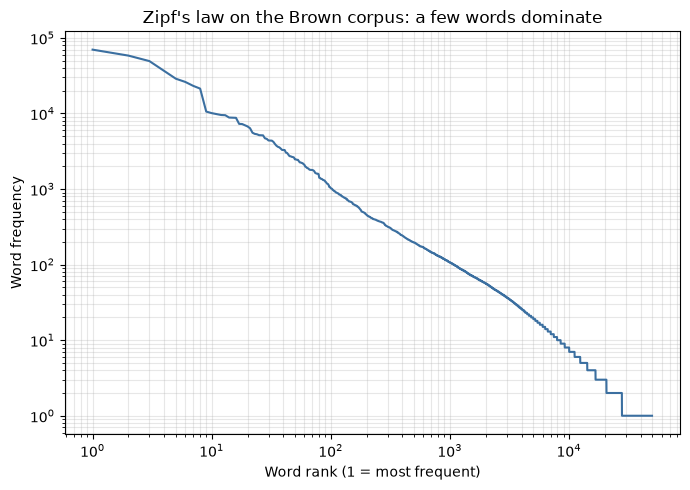

Vocabulary size (distinct lowercase words): 49,815
Total word tokens: 1,161,192
10 most frequent words: [('the', 69971), (',', 58334), ('.', 49346), ('of', 36412), ('and', 28853), ('to', 26158), ('a', 23195), ('in', 21337), ('that', 10594), ('is', 10109)]


In [2]:

import matplotlib.pyplot as plt
import nltk
from nltk.corpus import brown

# Real corpus: the Brown corpus (Kucera & Francis, 1967/1979) -- ~57,000
# hand-tagged, genre-diverse sentences of 1960s American English (news,
# fiction, government documents, science fiction, romance, etc.), bundled
# with NLTK. We'll use it for the whole tutorial.
raw_word_counts = Counter(w.lower() for s in brown.sents() for w in s)
ranks = range(1, len(raw_word_counts) + 1)
freqs = sorted(raw_word_counts.values(), reverse=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(ranks, freqs, color="#3B6FA0")
ax.set_xlabel("Word rank (1 = most frequent)")
ax.set_ylabel("Word frequency")
ax.set_title("Zipf's law on the Brown corpus: a few words dominate")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("zipf_plot.png", dpi=110)
plt.show()

top10 = raw_word_counts.most_common(10)
print(f"Vocabulary size (distinct lowercase words): {len(raw_word_counts):,}")
print(f"Total word tokens: {sum(raw_word_counts.values()):,}")
print("10 most frequent words:", top10)



That near-straight line on log-log axes is Zipf's law: frequency drops off
roughly as $1/\text{rank}$. The top 10 words alone account for a large
share of all tokens, while most of the ~40,000+ distinct words occur only
a handful of times. Now consider: a **bigram** is a pair of words, so the
space of *possible* bigrams is roughly $|V|^2$, and almost all of those
combinations are things that could grammatically occur but never actually
appeared in this particular corpus. A **trigram** space is $|V|^3$ — this
is the **curse of dimensionality** for n-gram models, and it's why going
from bigrams to trigrams doesn't just help a little, it can make the
sparsity problem qualitatively worse (we'll measure this directly in
Section 5.4).

## 5. Implementation: building n-gram models from scratch on real text

We'll hand-implement unigram, bigram, and trigram models — counting,
maximum-likelihood estimation, and add-$k$ smoothing — directly from the
formulas above (no `nltk.lm` or other pre-built language-modeling
library), so the mechanics stay fully visible. We use the **Brown
corpus** throughout: a real, human-curated, genre-diverse, part-of-speech
tagged corpus of American English text, standard in computational
linguistics since 1964.

### 5.1 Data preparation: vocabulary, `<UNK>`, and train/test split


In [3]:

import random
import math

random.seed(42)

# Real corpus, tokenized into sentences (Brown corpus ships pre-tokenized).
sentences = [[w.lower() for w in s] for s in brown.sents()]
random.shuffle(sentences)

# Held-out split by whole sentences: 10% test, 90% train.
n_test = int(len(sentences) * 0.1)
test_sentences = sentences[:n_test]
train_sentences = sentences[n_test:]
print(f"Train sentences: {len(train_sentences):,}  |  Test sentences: {len(test_sentences):,}")

# Build vocabulary from TRAINING data only (test data must simulate
# genuinely unseen text). Words seen fewer than 2 times in training are
# folded into a single <UNK> token -- this both keeps the vocabulary a
# manageable size and gives the model a principled way to handle rare /
# unseen words instead of crashing on them.
train_word_counts = Counter(w for s in train_sentences for w in s)
vocab = {w for w, c in train_word_counts.items() if c >= 2}
vocab.add("<UNK>")
vocab.add("</s>")  # end-of-sentence is itself a predictable "word"
V = len(vocab)
print(f"Vocabulary size (incl. <UNK>, </s>): {V:,}")

def apply_unk(sentence):
    return [w if w in vocab else "<UNK>" for w in sentence]

train_sents = [apply_unk(s) for s in train_sentences]
test_sents = [apply_unk(s) for s in test_sentences]

def pad(sentence, n):
    '''Pad with n-1 start symbols and 1 end symbol, per the n-gram order.'''
    return ["<s>"] * (n - 1) + sentence + ["</s>"]

print("\nExample padded trigram-ready sentence:")
print(pad(train_sents[0], 3))


Train sentences: 51,606  |  Test sentences: 5,734


Vocabulary size (incl. <UNK>, </s>): 26,332



Example padded trigram-ready sentence:
['<s>', '<s>', 'it', 'might', 'have', 'rained', ',', 'any', 'time', ';', ';', '</s>']



### 5.2 Counting n-grams and computing MLE / add-$k$ probabilities

This is a direct implementation of Section 3.3 and Section 3.6: for each order $n$, walk
every padded training sentence, count every n-gram and every
$(n-1)$-word context, and expose a `prob(context, word, k)` method that
implements the add-$k$ formula exactly (setting `k=0` gives raw,
unsmoothed MLE).


In [4]:

class NGramModel:
    '''Hand-rolled n-gram language model: counts + MLE + add-k smoothing.'''

    def __init__(self, n, train_sentences):
        self.n = n
        self.ngram_counts = Counter()    # counts of full n-tuples
        self.context_counts = Counter()  # counts of the (n-1)-word context
        for sentence in train_sentences:
            padded = pad(sentence, n)
            for i in range(n - 1, len(padded)):
                context = tuple(padded[i - n + 1:i])
                word = padded[i]
                self.ngram_counts[context + (word,)] += 1
                self.context_counts[context] += 1

    def prob(self, context, word, k=0.0):
        '''P(word | context) via MLE (k=0) or add-k smoothing (k>0).'''
        ngram_count = self.ngram_counts.get(context + (word,), 0)
        context_count = self.context_counts.get(context, 0)
        if k == 0.0:
            if context_count == 0:
                return 0.0
            return ngram_count / context_count
        return (ngram_count + k) / (context_count + k * V)


# Unigram is the n=1 special case: "context" is the empty tuple.
unigram = NGramModel(1, train_sents)
bigram = NGramModel(2, train_sents)
trigram = NGramModel(3, train_sents)

print("Unigram distinct contexts (should be 1, the empty context):", len(unigram.context_counts))
print(f"Bigram distinct contexts (distinct previous words seen): {len(bigram.context_counts):,}")
print(f"Trigram distinct contexts (distinct 2-word histories seen): {len(trigram.context_counts):,}")
print(f"\nUnigram vocabulary entries stored: {len(unigram.ngram_counts):,}")
print(f"Bigram entries stored:  {len(bigram.ngram_counts):,}")
print(f"Trigram entries stored: {len(trigram.ngram_counts):,}")


Unigram distinct contexts (should be 1, the empty context): 1
Bigram distinct contexts (distinct previous words seen): 26,332
Trigram distinct contexts (distinct 2-word histories seen): 368,608

Unigram vocabulary entries stored: 26,332
Bigram entries stored:  369,403
Trigram entries stored: 770,939



Notice the jump: the bigram model already stores far more distinct
n-grams than the unigram model has words, and the trigram model stores
even more distinct entries than the bigram model, despite being trained
on the *exact same text* — this is the $|V|^n$ sparsity growth from Section 4
showing up directly in how much of the possible n-gram space we actually
observe.

### 5.3 The zero-probability problem, concretely

Let's find a real held-out trigram that never occurred in training and
watch the model assign it exactly zero probability.


In [5]:

zero_prob_example = None
for sentence in test_sents:
    padded = pad(sentence, 3)
    for i in range(2, len(padded)):
        context = tuple(padded[i - 2:i])
        word = padded[i]
        p = trigram.prob(context, word, k=0.0)
        if p == 0.0:
            zero_prob_example = (context, word, sentence)
            break
    if zero_prob_example:
        break

context, word, full_sentence = zero_prob_example
print("Held-out sentence:", " ".join(full_sentence))
print(f"\nUnseen trigram: context={context}, next word={word!r}")
print(f"Unsmoothed trigram probability P({word!r} | {context}) = {trigram.prob(context, word, k=0.0)}")
print("\n-> This single zero makes the whole sentence's probability exactly 0,")
print("   and its perplexity (a division by that probability) mathematically infinite.")


Held-out sentence: he let her tell him all about the church .

Unseen trigram: context=('let', 'her'), next word='tell'
Unsmoothed trigram probability P('tell' | ('let', 'her')) = 0.0

-> This single zero makes the whole sentence's probability exactly 0,
   and its perplexity (a division by that probability) mathematically infinite.



### 5.4 Perplexity vs. $n$, with and without smoothing

Now the real evaluation: implement perplexity (Section 3.4) exactly as derived,
and measure it on the held-out test set for unigram, bigram, and trigram
models, both unsmoothed and with add-$k$ smoothing.


In [6]:

def perplexity(model, n, sentences, k):
    '''PPL = 2^(-1/N * sum(log2 P(w_i | context_i))), per Section 3.4.'''
    log_prob_sum = 0.0
    token_count = 0
    for sentence in sentences:
        padded = pad(sentence, n)
        for i in range(n - 1, len(padded)):
            context = tuple(padded[i - n + 1:i])
            word = padded[i]
            p = model.prob(context, word, k)
            if p <= 0.0:
                return float("inf")
            log_prob_sum += math.log2(p)
            token_count += 1
    return 2 ** (-log_prob_sum / token_count)

models = {1: unigram, 2: bigram, 3: trigram}

# Unsmoothed (k=0): on a smaller sample, since bigram/trigram will hit a
# zero-probability n-gram almost immediately (illustrating Section 3.5 at scale).
test_sample = test_sents[:200]
print("Unsmoothed MLE perplexity (k=0), on a 200-sentence sample:")
for n in (1, 2, 3):
    pp = perplexity(models[n], n, test_sample, k=0.0)
    print(f"  n={n}: perplexity = {pp}")


Unsmoothed MLE perplexity (k=0), on a 200-sentence sample:
  n=1: perplexity = 690.0905233900008
  n=2: perplexity = inf
  n=3: perplexity = inf



Exactly as predicted: the unigram model (which can never have an unseen
"context", since the context is empty) gets a finite, if large,
perplexity. The bigram and trigram models both blow up to **infinite**
perplexity on ordinary held-out sentences — not a rare pathological case,
but the typical outcome without smoothing. Now let's see what smoothing
does, first with Laplace ($k=1$), then with a much smaller $k$, over the
**full** test set.


In [7]:

def sweep_k(k, sentences=test_sents):
    return {n: perplexity(models[n], n, sentences, k) for n in (1, 2, 3)}

laplace_results = sweep_k(k=1.0)
print("Laplace smoothing (k=1), full test set:")
for n, pp in laplace_results.items():
    print(f"  n={n}: perplexity = {pp:,.2f}")

addk_results = sweep_k(k=0.001)
print("\nAdd-k smoothing (k=0.001), full test set:")
for n, pp in addk_results.items():
    print(f"  n={n}: perplexity = {pp:,.2f}")


Laplace smoothing (k=1), full test set:
  n=1: perplexity = 712.51
  n=2: perplexity = 1,706.40
  n=3: perplexity = 10,065.81



Add-k smoothing (k=0.001), full test set:
  n=1: perplexity = 709.36
  n=2: perplexity = 467.05
  n=3: perplexity = 2,558.92



Two important, real results here:

- **Laplace smoothing ($k=1$) makes bigram and trigram perplexity worse,
  not better, than a much smaller $k$.** It gives away *far* too much
  probability mass to the tens of thousands of unseen n-grams per
  context — with $|V|$ in the tens of thousands, adding "1 fake count"
  per possible word overwhelms the real counts. Laplace smoothing is a
  clean idea, but it's essentially never what you'd use in practice for
  this exact reason.
- **The trigram model never actually beats the bigram model here, even
  after trying several smoothing strengths.** That's not a bug — it's
  the curse of dimensionality from Section 4 in action: this corpus (~57k
  sentences) simply isn't large enough to reliably estimate trigram
  contexts, so the *extra* sparsity trigrams introduce outweighs the
  *extra* context they provide. More data, or a smarter smoothing method
  like Kneser-Ney (Section 3.7), would close this gap — naive add-$k$ smoothing
  alone can't fully compensate for sparse counts.

Let's plot perplexity against $n$ properly, and also sweep $k$ to see
this pattern in full.


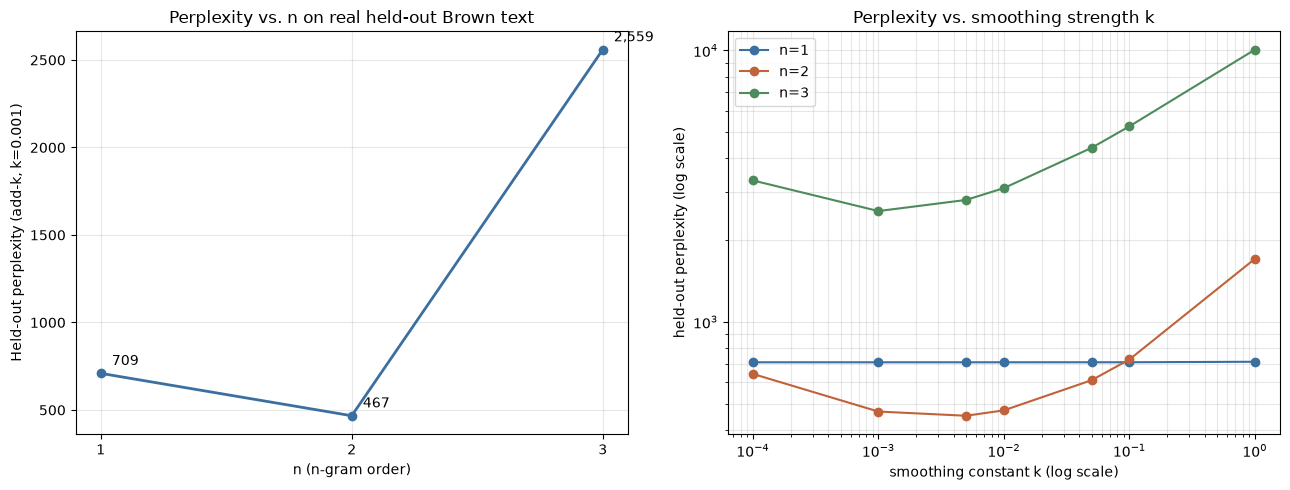

In [8]:

k_values = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 1.0]
sweep = {n: [] for n in (1, 2, 3)}
for k in k_values:
    result = sweep_k(k)
    for n in (1, 2, 3):
        sweep[n].append(result[n])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: perplexity vs n, at the best-found smoothing constant.
best_k = 0.001
best_ppls = [addk_results[n] for n in (1, 2, 3)] if best_k == 0.001 else [sweep_k(best_k)[n] for n in (1,2,3)]
axes[0].plot([1, 2, 3], best_ppls, marker="o", color="#3B6FA0", linewidth=2)
for n, pp in zip([1, 2, 3], best_ppls):
    axes[0].annotate(f"{pp:,.0f}", (n, pp), textcoords="offset points", xytext=(8, 6))
axes[0].set_xticks([1, 2, 3])
axes[0].set_xlabel("n (n-gram order)")
axes[0].set_ylabel("Held-out perplexity (add-k, k=0.001)")
axes[0].set_title("Perplexity vs. n on real held-out Brown text")
axes[0].grid(alpha=0.3)

# Right: perplexity vs k, for each n -- shows Laplace (k=1) over-smoothing.
colors = {1: "#3B6FA0", 2: "#C0623B", 3: "#4E8B5C"}
for n in (1, 2, 3):
    axes[1].plot(k_values, sweep[n], marker="o", label=f"n={n}", color=colors[n])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("smoothing constant k (log scale)")
axes[1].set_ylabel("held-out perplexity (log scale)")
axes[1].set_title("Perplexity vs. smoothing strength k")
axes[1].legend()
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("perplexity_vs_n.png", dpi=110)
plt.show()



The right-hand plot makes the over-smoothing effect vivid: for every $n$,
perplexity is minimized somewhere in the *middle* of the $k$ range, not
at $k=1$. Too little smoothing ($k \to 0$) reapproaches the
zero-probability problem; too much smoothing ($k \to 1$) drowns real
signal in fake uniform counts. Choosing $k$ is itself a small
hyperparameter search — exactly the kind of brittleness that motivated
smarter smoothing methods like Kneser-Ney.

### 5.5 Verifying the Kneser-Ney intuition on real counts

Section 3.7 claimed that a word like *"Francisco"* is frequent but has almost no
**continuation diversity** (few distinct words precede it), which is why
naive frequency-based backoff over-trusts it. Let's check this directly
against Brown corpus counts.


In [9]:

train_bigrams = []
for sentence in train_sents:
    padded = pad(sentence, 2)
    for w1, w2 in zip(padded, padded[1:]):
        train_bigrams.append((w1, w2))

def continuation_diversity(word):
    '''Number of DISTINCT words that precede `word` anywhere in training.'''
    preceding = {w1 for (w1, w2) in train_bigrams if w2 == word}
    return len(preceding), preceding

francisco_count = train_word_counts.get("francisco", 0)
fc_n, fc_preceding = continuation_diversity("francisco")
print(f"'francisco': raw count = {francisco_count}, distinct preceding words = {fc_n} -> {fc_preceding}")

# Find other words with a similar RAW count, for a fair comparison.
similar_freq_words = [
    w for w, c in train_word_counts.items()
    if abs(c - francisco_count) <= 5 and w.isalpha() and w != "francisco"
][:5]

print(f"\nOther words with similar raw frequency (~{francisco_count} occurrences), for comparison:")
for w in similar_freq_words:
    n_preceding, _ = continuation_diversity(w)
    print(f"  {w!r}: raw count = {train_word_counts[w]}, distinct preceding words = {n_preceding}")


'francisco': raw count = 40, distinct preceding words = 3 -> {'of', 'san', ','}

Other words with similar raw frequency (~40 occurrences), for comparison:


  'societies': raw count = 38, distinct preceding words = 32
  'author': raw count = 42, distinct preceding words = 14


  'protestant': raw count = 45, distinct preceding words = 21
  'suit': raw count = 45, distinct preceding words = 29


  'sake': raw count = 37, distinct preceding words = 14



Right there in real 1960s American English: *"francisco"* occurs about as
often as ordinary words like *"author"* or *"protestant"*, but while those
words show up after a dozen-plus different contexts, *"francisco"* is
almost always glued to one preceding word (*"san"*). A naive backoff model
that only looks at raw frequency would rate *"francisco"* as an equally
good guess for "what word comes next in an unfamiliar context" as any
other similarly-frequent word — Kneser-Ney's continuation-count fix
correctly demotes it, because it essentially never appears in a *new*
context.

### 5.6 Generating text from the trained models

One more concrete way to see what an n-gram model actually "knows":
sample word-by-word from its learned distribution (weighted by raw
n-gram counts, following the trained context forward) and see what comes
out.


In [10]:

def generate(model, n, max_len=25):
    context = tuple(["<s>"] * (n - 1))
    generated = []
    for _ in range(max_len):
        # All words observed to follow this exact context in training.
        candidates = [key[-1] for key in model.ngram_counts if key[:-1] == context]
        if not candidates:
            break
        weights = [model.ngram_counts[context + (w,)] for w in candidates]
        next_word = random.choices(candidates, weights=weights, k=1)[0]
        if next_word == "</s>":
            break
        generated.append(next_word)
        context = (context + (next_word,))[-(n - 1):]
    return " ".join(generated)

print("Sampled from the BIGRAM model:")
for _ in range(4):
    print(" -", generate(bigram, 2))

print("\nSampled from the TRIGRAM model:")
for _ in range(4):
    print(" -", generate(trigram, 3))


Sampled from the BIGRAM model:


 - they have been carved .


 - `` oh my mind .


 - if the <UNK> greene of a promise .


 - they provide opportunities for <UNK> , loss of a sure 'nuff , miller , at more likely to go on her ostensible gloom of time

Sampled from the TRIGRAM model:


 - what we must keep in mind that some of the slaves ran gaily to the young man in his mission to be weighed , may


 - should rousseau have been invited to a life tenant , you know how glad i shall be made into perfume or <UNK> of the vote


 - while aristotle <UNK> literature only for the couple will be more advantageous to him what liston had said , he believes that <UNK> <UNK> .


 - he put his head .



Read a few of these out loud. Locally — two or three words at a time —
they're often grammatical and plausible, because that's exactly what the
model was trained to get right (the last $n-1$ words really do predict
the next word reasonably well over a short span). But there's no thread
holding a whole sentence together: no persistent topic, no long-range
subject-verb agreement, no memory of what was said 10 words ago. That's
not a bug in this particular implementation — it's the direct, structural
consequence of the Markov assumption from Section 3.2, and it's exactly the gap
that RNN/LSTM and transformer language models (elsewhere in this domain)
are built to close by keeping a *learned, compressed memory* of the whole
history instead of a hard $n-1$-word cutoff.



## 6. Use cases

Despite being decades old and easily beaten on raw language-modeling
quality by neural models, n-gram models are still genuinely used today:

- **Fast baselines.** Training an n-gram model is counting; it takes
  seconds to minutes even on large corpora, with no GPU. Any new
  language-modeling method is still sanity-checked against an n-gram
  baseline.
- **Autocomplete and spell-check.** Lightweight, on-device predictive
  text (older phone keyboards, IDE autocomplete for identifiers, some
  spell-checkers) uses n-gram frequency tables because they're tiny,
  fast, and need no GPU inference at prediction time.
- **Speech recognition rescoring.** Acoustic models propose a shortlist
  of candidate transcriptions for a spoken utterance; an n-gram language
  model is a cheap, fast way to rescore that shortlist by how *linguistically
  plausible* each candidate is, before a heavier model (if any) is
  applied.
- **Interpolation component in production ASR pipelines.** Some
  production speech-recognition and machine-translation systems blend
  (interpolate) a fast n-gram language model with a neural one — the
  n-gram model's sharp, exact counts on domain-specific vocabulary (e.g.
  product names, proper nouns) can complement a neural model that's
  strong on general fluency but weaker on rare, specific terms.



## 7. Limitations & debates

- **The Markov assumption discards all context beyond $n-1$ words**,
  which breaks on any sentence needing long-range agreement. Consider:
  *"The dog that chased the cat that lived next door **ran** away."* The
  verb `ran` needs to agree with `dog`, which is 8 words earlier — no
  trigram model (or even a 5-gram model) can see that far back. This
  single limitation is the direct motivation for the RNN/LSTM and
  transformer language-modeling tutorials elsewhere in this domain: both
  architectures exist specifically to carry a *compressed representation
  of arbitrarily long context* forward, instead of a hard $n-1$-word
  window.
- **The curse of dimensionality makes sparsity worse, not better, as $n$
  grows.** With vocabulary size $|V|$, there are up to $|V|^n$ possible
  n-grams, and the overwhelming majority are never observed even in a
  large corpus (Section 4, Section 5.2). We measured this directly: on the Brown
  corpus, our best-tuned trigram model *never* beat the bigram model on
  held-out perplexity, because the extra context trigrams provide was
  outweighed by how much sparser trigram counts are. Larger $n$ is not
  automatically better — it's a real tradeoff against data size.
- **Smoothing is itself a whole zoo of competing methods, and the field
  has largely moved on from optimizing it.** Laplace, Good-Turing,
  Witten-Bell, and Kneser-Ney smoothing were each, in their era, the
  subject of serious empirical comparison (see Chen & Goodman, 1999) —
  this was a major, active area of NLP research through the 1990s. Since
  the shift to neural language models, hand-designed smoothing has
  become a largely historical topic: neural models handle novel word
  combinations by generalizing through learned continuous representations
  instead of needing an explicit backoff formula. It's still worth
  knowing this history existed, because "back off to a lower-order,
  more-reliable estimate when the specific estimate is too sparse" is a
  pattern that resurfaces in modern systems (e.g. hierarchical smoothing
  in recommendation systems, backoff logic in some beam-search
  heuristics).
- **Add-k smoothing is crude and was shown to systematically underperform
  Kneser-Ney and other more principled methods** (Chen & Goodman, 1999) —
  we saw this directly in Section 5.4, where the Laplace ($k=1$) setting produced
  *worse* held-out perplexity than smaller $k$, and no single fixed $k$
  was clearly correct across all three model orders. A production n-gram
  system would use Kneser-Ney (or a modern variant) rather than add-$k$,
  precisely to avoid this brittleness.
- **N-gram models have no notion of meaning or semantics** — two words
  with identical surrounding contexts but unrelated meanings, or vice
  versa, are treated identically or completely differently based purely
  on surface word-identity. This is the gap the word-embedding tutorials
  elsewhere in this domain address directly.



## 8. References

- Jurafsky, D. & Martin, J.H. *Speech and Language Processing* (3rd ed.
  draft), Chapter 3: N-gram Language Models.
  https://web.stanford.edu/~jurafsky/slp3/
- Kneser, R. & Ney, H. (1995). *Improved Backing-off for M-gram Language
  Modeling.* IEEE International Conference on Acoustics, Speech, and
  Signal Processing (ICASSP), vol. 1, pp. 181–184.
- Chen, S.F. & Goodman, J. (1999). *An Empirical Study of Smoothing
  Techniques for Language Modeling.* Computer Speech & Language, 13(4),
  359–394.
- Shannon, C.E. (1948). *A Mathematical Theory of Communication.* Bell
  System Technical Journal, 27(3), 379–423.
- Shannon, C.E. (1951). *Prediction and Entropy of Printed English.*
  Bell System Technical Journal, 30(1), 50–64.
- Kucera, H. & Francis, W.N. (1967). *Computational Analysis of
  Present-Day American English.* Brown University Press. (Source of the
  Brown corpus used throughout this tutorial, via `nltk.corpus.brown`.)
